# Classical Spin Reservoir Demo (Python)

In this demo, we process the MNIST dataset with a classical spin reservoir. The dynamics of the Rydberg Hamiltonian are simulated by integrating differential equations governing the classical spin reservoir evolution.

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist
import time
from tqdm.auto import tqdm

## Download the MNIST dataset

In [3]:
# Load MNIST data
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# We'll use a subset to make the demonstration faster
num_train = 10000
num_test = 1000

# Flatten images
X_train = X_train_full[:num_train].reshape(num_train, -1).astype(np.float32)
y_train = y_train_full[:num_train]

X_test = X_test_full[:num_test].reshape(num_test, -1).astype(np.float32)
y_test = y_test_full[:num_test]

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training features shape: (10000, 784)
Test features shape: (1000, 784)


## The Classical Spin Reservoir (CRC) Model
The CRC is derived by promoting all the qubits (spin 1/2's) to $S\rightarrow\infty$, thus making them classical unit vectors ($\hat{S}$). The dequantized dynamics of the Rydberg Hamiltonian is described by:
\begin{equation}
    \frac{\mathrm{d} \hat{S}_i}{\mathrm{d} t}= \frac{\partial H[\hat{S}]}{\partial \hat{S}_i} \times \hat{S}
\end{equation}
where the effective instantaneous magnetic field acting on the $\hat{S}_i$ is:
\begin{equation}
    \frac{\partial H[\hat{S}]}{\partial \hat{S}_i}= \frac{\Omega(t)}{2} \left[\hat{x}\cos{\phi(t)}+\hat{y}\sin{\phi(t)}\right] + \left[-\frac{\Delta_i(t)}{2} + \frac{1}{4} \sum_{j\neq i}V_{ij}\left(1 + \hat{S}_j^{(z)} \right)\right] \hat{z}
\end{equation}
Thus, the dynamics of $N_q$-classical spins is efficiently simulated by integrating a system of 3 $N_q$ equations.

### Explanation
**1. Dequantization (classical approximation)**
- Normally, the reservoir relies on quantum mechanics (qubits, which are spin-$1/2$ systems). This model "dequantizes" the spin quantum number limit $S\!\to\!\infty$; this approximation turns qubits into classical unit vectors $\hat{S}$ (3‑D arrows).

**2. Equation of motion**
- The equation $\frac{d\hat{S}_i}{dt}= \frac{\partial H[\hat{S}]}{\partial \hat{S}_i}\times\hat{S}_i.$ describes how each classical spin vector $\hat{S}_i$ evolves over time. This is analogous to the Larmor precession equation, where a classical magnetic dipole precesses around an external magnetic field. Here, $\frac{\partial H[\hat{S}]}{\partial \hat{S}_i}$ acts as the effective instantaneous magnetic field.

**3. Effective magnetic field**
- **Horizontal (X‑Y) drive**  
  $\frac{\Omega(t)}{2} \left[\hat{x}\cos{\phi(t)}+\hat{y}\sin{\phi(t)}\right]$ represents the external driving laser (or microwave) field that makes all the spins rotate in plane, parameterized by the Rabi frequency $\Omega(t)$ and the laser phase $\phi(t)$.

- **Vertical (Z) bias**  
  $\left[-\frac{\Delta_i(t)}{2} + \frac{1}{4} \sum_{j\neq i}V_{ij}\left(1 + \hat{S}j^{(z)} \right)\right] \hat{z}$ represents the local detuning for each atom $\Delta_i(t)$ (to input data like the MNIST pixels to be fed into the system) combined with the $V{ij}$ Van der Waals interactions with all other spins (signed summation) (the "crosstalk" between the different atoms).

- A true quantum reservoir of $N_q$ would require $2^{N}$ amplitudes. The classical version only needs $3N$ ordinary differential equations (the X, Y, Z components of each spin).  
- This makes the simulation fast while still keeping rich, nonlinear dynamics for machine‑learning tasks.

The code implementation follows directly from these equations (`ClassicalDetuningLayer` class using scipy.integrate.solve_ivp):
- generate_Vmat(): Builds the Van‑der‑Waals interaction matrix $V_{ij} = C6 / |r_i - r_j|^6$ and then the diagonal shift $VDel_i = Σ_j V_{ij}$ (VDel is term $\frac14\sum_{j\neq i}V_{ij}$, summed once per spin, so we pre‑compute it for speed.)
- deriv(): Computes du/dt for all spins. u is a flat vector [x0,y0,z0, x1,y1,z1, …]. 
  - Delta is the detuning vector that injects the data (MNIST pixel values).
  - Omega drives the transverse (X‑Y) rotation.
- apply_classical_layer_single(): Runs the reservoir for ONE input vector `x` (the detuning profile). and returns a flattened array of the requested readout. 
  - x is the detuning vector derived from input image (after PCA).
  - Readout option 'zz' concatenates the raw z‑components with all pairwise products (“high‑dimensional” reservoir features).
  - Output is column‑major flattened, matching the shape expected later by the SVM.
- apply_classical_layer_batch(): Apply the reservoir to every row of `X_features` (each row = one image). Returns an array of shape (n_samples, n_features_out). Wraps the single‑sample routine in a progress‑bar (tqdm). Produces the embedding matrix that is later fed to the linear SVM.

In [ ]:
class ClassicalDetuningLayer:
    def __init__(self, atoms, Omega, t_start, t_end, step, state, readout='zz', C6=862690*2*np.pi):
        self.atoms = np.array(atoms)# 2‑D positions of the spins (nm), shape (N, 2)
        self.Omega = Omega          # global driving amplitude (Rabi frequency)
        self.t_start = t_start      # time window start
        self.t_end = t_end          # ...and end
        self.step = step            # integration step size
        self.state = np.array(state)# initial spin state (flattened [x,y,z] * N), length 3*N
        self.readout = readout      # which component(s) to output: 'z' or 'zz'
        self.C6 = C6
        
def generate_Vmat(locs, C6):
    nsites = len(locs)
    Vmat = np.zeros((nsites, nsites))
    VDel = np.zeros(nsites)
    for i in range(nsites):
        for j in range(nsites):
            if i != j:
                dist = np.linalg.norm(locs[i] - locs[j])
                Vmat[i, j] = C6 / (dist ** 6)
                VDel[i] += Vmat[i, j]
    return Vmat, VDel

def deriv(t, u, nsites, Delta, Omega, Vmat, VDel):
    du = np.zeros_like(u)
    # Extract z components of all spins: indices 2, 5, 8...
    sz = u[2::3]            # shape (nsites,)
    Bv = Vmat @ sz          # Σ_j V_ij * S_j^z  (vector length nsites)
    
    for i in range(nsites):
        # instantaneous magnetic field for spin i (Eq. 2)
        Bi = np.array([Omega, 0, -Delta[i] + Bv[i]/2 + VDel[i]/2]) / 2.0
        s = u[3*i : 3*i+3]  # current (x,y,z) of spin i
        # Cross product: Bi x S → dS_i/dt
        du[3*i]   = Bi[2]*s[1] - Bi[1]*s[2]
        du[3*i+1] = Bi[0]*s[2] - Bi[2]*s[0]
        du[3*i+2] = Bi[1]*s[0] - Bi[0]*s[1]
    return du

def apply_classical_layer_single(layer, x):
    nsites = len(layer.atoms)
    # interaction matrix for this layer (cached inside the layer)
    Vmat, VDel = generate_Vmat(layer.atoms, layer.C6)
    
    t_span = (layer.t_start, layer.t_end)
    t_eval = np.arange(layer.t_start + layer.step, layer.t_end + 1e-9, layer.step)
    
    # solve the ODE (using scipy’s RK45 with modest tolerances)
    sol = solve_ivp(deriv, t_span, layer.state, t_eval=t_eval, 
                    args=(nsites, x, layer.Omega, Vmat, VDel), 
                    method='RK45', rtol=1e-3, atol=1e-6)
    
    # sol.y has shape (3*nsites, num_steps)
    y = sol.y
    num_steps = y.shape[1]  
    
    # only the z‑components are needed for readout
    sol_z = y[2::3, :] # shape (nsites, num_steps)
    
    if layer.readout == 'zz':
        # pairwise products of every distinct spin pair (i<j)
        out31 = [sol_z[i, :] * sol_z[j, :]
                 for i in range(nsites)
                 for j in range(i+1, nsites)]
        out31 = np.array(out31)         # shape (nsites*(nsites-1)/2, num_steps)
        out = np.vstack([sol_z, out31])
    elif layer.readout == 'z':
        out = sol_z
    else:
        out = sol_z # fallback to just z
        
    # flatten column‑wise so that time runs continuously: [z₀(t₀), z₁(t₀), …, z_N‑1(t₀),  z₀(t₁), …]
    return out.flatten(order='F')

def apply_classical_layer_batch(layer, X_features):
    outs = []
    for i in tqdm(range(X_features.shape[0]), desc="Simulating Dynamics"):
        res = apply_classical_layer_single(layer, X_features[i])
        outs.append(res)
    return np.array(outs)

## PCA Reduction and Setup
We use PCA to downsample the data into 8-dimensional vectors, which will be mapped to the detunings of 8 spins.

In [5]:
dim_pca = 8
pca = PCA(n_components=dim_pca)
X_pca_train = pca.fit_transform(X_train)
X_pca_test = pca.transform(X_test)

# Normalize features to be within the range [-6.0, 6.0]
Delta_max = 6.0
spectral = max(np.max(np.abs(X_pca_train)), np.max(np.abs(X_pca_test)))

X_qrc_train = X_pca_train / spectral * Delta_max
X_qrc_test = X_pca_test / spectral * Delta_max

print(f"PCA mapped training shape: {X_qrc_train.shape}")

PCA mapped training shape: (10000, 8)


## Creating and Running the CRC Layer
We place 8 atoms in a chain and simulate the dynamics for each image.

In [6]:
# Setup the classical layer
nsites = dim_pca
d = 10.0 # spacing
locs = np.array([[i*d, 0.0] for i in range(nsites)])

# Initial state: all spins pointing downwards (-1 in z)
u0 = np.zeros(3 * nsites)
u0[2::3] = -1.0

# Base configuration
pre_layer = ClassicalDetuningLayer(
    atoms=locs, 
    Omega=2*np.pi, 
    t_start=0.0, 
    t_end=4.0, 
    step=0.5, 
    state=u0,
    readout='zz',
    C6=862690*2*np.pi
)

# Run simulation
print("Generating training embeddings...")
embeddings_train = apply_classical_layer_batch(pre_layer, X_qrc_train)

print("Generating test embeddings...")
embeddings_test = apply_classical_layer_batch(pre_layer, X_qrc_test)

print(f"Generated embeddings shape (train): {embeddings_train.shape}")

Generating training embeddings...


Simulating Dynamics:   0%|          | 0/10000 [00:00<?, ?it/s]

Generating test embeddings...


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated embeddings shape (train): (10000, 288)


## Training Linear SVM
Let's train a linear SVM on the raw PCA embeddings vs. the CRC embeddings to observe the advantage of the spin reservoir's non-linear high-dimensional mapping.

In [7]:
def train_evaluate_svm(X_tr, y_tr, X_te, y_te, name=""):
    print(f"Training SVM on {name}...")
    svm = SVC(kernel='linear')
    
    start_time = time.time()
    svm.fit(X_tr, y_tr)
    train_time = time.time() - start_time
    
    train_acc = accuracy_score(y_tr, svm.predict(X_tr))
    test_acc = accuracy_score(y_te, svm.predict(X_te))
    
    print(f"[{name}] Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Time: {train_time:.2f}s")
    return train_acc, test_acc

# Baseline
train_evaluate_svm(X_qrc_train, y_train, X_qrc_test, y_test, name="PCA features (Baseline)")

# QRC Embeddings
train_evaluate_svm(embeddings_train, y_train, embeddings_test, y_test, name="CRC Embeddings")

Training SVM on PCA features (Baseline)...
[PCA features (Baseline)] Train Acc: 0.8250 | Test Acc: 0.8020 | Time: 1.34s
Training SVM on CRC Embeddings...
[CRC Embeddings] Train Acc: 0.9237 | Test Acc: 0.8740 | Time: 2.85s


(0.9237, 0.874)

## Tweaking Interaction Strength and Time Period
By exposing variables such as the atomic spacing `d` (which modifies the effective $V_{ij}$ interaction strength) and the simulation time `t_end`, we can tune the reservoir to improve accuracy. Below is a quick sweep over different `t_end` times to observe the effect.

--- Simulating for t_end = 2.0 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for t_end=2.0: 0.7980
--- Simulating for t_end = 4.0 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for t_end=4.0: 0.7820
--- Simulating for t_end = 6.0 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for t_end=6.0: 0.7740


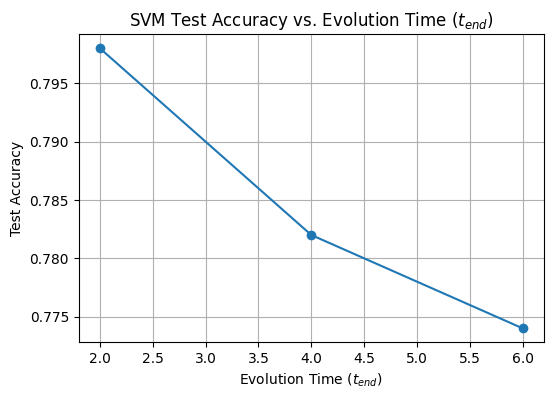

In [8]:
t_end_values = [2.0, 4.0, 6.0]
test_accuracies = []

# To make the sweep fast, we will test on a smaller subset (e.g. 1000 train samples)
sweep_train_idx = 1000
sweep_test_idx = 500

for t_e in t_end_values:
    # Update layer parameters
    layer_sweep = ClassicalDetuningLayer(
        atoms=locs, 
        Omega=2*np.pi, 
        t_start=0.0, 
        t_end=t_e, 
        step=0.5, 
        state=u0,
        readout='zz',
        C6=862690*2*np.pi
    )
    
    print(f"--- Simulating for t_end = {t_e} ---")
    emb_train_sweep = apply_classical_layer_batch(layer_sweep, X_qrc_train[:sweep_train_idx])
    emb_test_sweep = apply_classical_layer_batch(layer_sweep, X_qrc_test[:sweep_test_idx])
    
    # Train SVM on the subset
    svm = SVC(kernel='linear')
    svm.fit(emb_train_sweep, y_train[:sweep_train_idx])
    acc = accuracy_score(y_test[:sweep_test_idx], svm.predict(emb_test_sweep))
    test_accuracies.append(acc)
    print(f"Accuracy for t_end={t_e}: {acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(t_end_values, test_accuracies, marker='o')
plt.title('SVM Test Accuracy vs. Evolution Time ($t_{end}$)')
plt.xlabel('Evolution Time ($t_{end}$)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

## Optimizing Atomic Spacing (d)
Now let's vary the atomic spacing $d$, which modifies the $V_{ij}$ interaction strength, to see if we can further improve accuracy. We'll use $t_{end}=2.0$ based on the previous sweep.

--- Simulating for d = 6.0 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for d=6.0: 0.5220
--- Simulating for d = 8.0 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for d=12.0: 0.7480
--- Simulating for d = 14.0 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for d=14.0: 0.6020


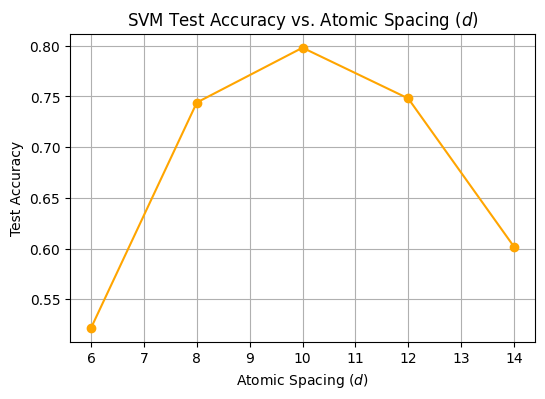

In [9]:
d_values = [6.0, 8.0, 10.0, 12.0, 14.0]
test_accuracies_d = []

for d_val in d_values:
    locs_sweep = np.array([[i*d_val, 0.0] for i in range(nsites)])
    
    layer_sweep_d = ClassicalDetuningLayer(
        atoms=locs_sweep, 
        Omega=2*np.pi, 
        t_start=0.0, 
        t_end=2.0, 
        step=0.5, 
        state=u0,
        readout='zz',
        C6=862690*2*np.pi
    )
    
    print(f"--- Simulating for d = {d_val} ---")
    emb_train_d = apply_classical_layer_batch(layer_sweep_d, X_qrc_train[:sweep_train_idx])
    emb_test_d = apply_classical_layer_batch(layer_sweep_d, X_qrc_test[:sweep_test_idx])
    
    svm_d = SVC(kernel='linear')
    svm_d.fit(emb_train_d, y_train[:sweep_train_idx])
    acc_d = accuracy_score(y_test[:sweep_test_idx], svm_d.predict(emb_test_d))
    test_accuracies_d.append(acc_d)
    print(f"Accuracy for d={d_val}: {acc_d:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(d_values, test_accuracies_d, marker='o', color='orange')
plt.title('SVM Test Accuracy vs. Atomic Spacing ($d$)')
plt.xlabel('Atomic Spacing ($d$)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

## Optimizing Interaction Strength (C6)
Alternatively, we can directly scale the $C_6$ coefficient. Let's fix $d=10.0$ and $t_{end}=2.0$, and sweep over $C_6$.

--- Simulating for C6 scale = 0.1 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for C6 scale=0.1: 0.5520
--- Simulating for C6 scale = 0.5 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for C6 scale=2.0: 0.7660
--- Simulating for C6 scale = 5.0 ---


Simulating Dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

Simulating Dynamics:   0%|          | 0/500 [00:00<?, ?it/s]

Accuracy for C6 scale=5.0: 0.7100


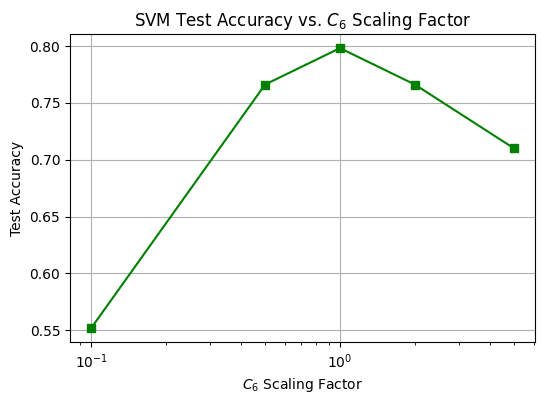

In [10]:
C6_scales = [0.1, 0.5, 1.0, 2.0, 5.0]
test_accuracies_C6 = []

for scale in C6_scales:
    C6_val = 862690 * 2 * np.pi * scale
    
    layer_sweep_C6 = ClassicalDetuningLayer(
        atoms=locs, 
        Omega=2*np.pi, 
        t_start=0.0, 
        t_end=2.0, 
        step=0.5, 
        state=u0,
        readout='zz',
        C6=C6_val
    )
    
    print(f"--- Simulating for C6 scale = {scale} ---")
    emb_train_C6 = apply_classical_layer_batch(layer_sweep_C6, X_qrc_train[:sweep_train_idx])
    emb_test_C6 = apply_classical_layer_batch(layer_sweep_C6, X_qrc_test[:sweep_test_idx])
    
    svm_C6 = SVC(kernel='linear')
    svm_C6.fit(emb_train_C6, y_train[:sweep_train_idx])
    acc_C6 = accuracy_score(y_test[:sweep_test_idx], svm_C6.predict(emb_test_C6))
    test_accuracies_C6.append(acc_C6)
    print(f"Accuracy for C6 scale={scale}: {acc_C6:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(C6_scales, test_accuracies_C6, marker='s', color='green')
plt.title('SVM Test Accuracy vs. $C_6$ Scaling Factor')
plt.xlabel('$C_6$ Scaling Factor')
plt.ylabel('Test Accuracy')
plt.xscale('log')
plt.grid(True)
plt.show()

Most optimum parameters found for this case: `t = 2.0`, `d = 10.0`,`C6 = 1.0` 
You can also directly to modify the $V_{ij}$ interaction strength and optimize the reservoir for your particular dataset!